# Lung Cancer Survey Data — Comprehensive Medical Statistical Analysis

**Skills used:** medical-stat-three-line-table, medical-stat-stat-plot, medical-stat-ttest, medical-stat-chisq, medical-stat-correlation, medical-stat-logistic-reg, medical-stat-roc, medical-stat-pca, medical-stat-pca-vis

**Dataset:** `survey lung cancer.csv` (n = 309)

**Outcome variable:** LUNG_CANCER (YES/NO)

**Variables:** GENDER, AGE, SMOKING, YELLOW_FINGERS, ANXIETY, PEER_PRESSURE, CHRONIC DISEASE, FATIGUE, ALLERGY, WHEEZING, ALCOHOL CONSUMING, COUGHING, SHORTNESS OF BREATH, SWALLOWING DIFFICULTY, CHEST PAIN

In [1]:
.libPaths(c("/Users/leigao/Library/R/arm64/4.2/library", "/Library/Frameworks/R.framework/Versions/4.2-arm64/Resources/library"))

# ============================================================
# SECTION 0: Setup and package loading
# ============================================================
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(broom)
  library(pROC)
  library(corrplot)
  library(MASS)
  library(patchwork)
  library(scales)
  library(cluster)
  library(survival)
})

data_dir <- "/Users/leigao/Documents/R-Medical-Statistics-Skills/example/lung-cancer/data"
out_dir <- "/Users/leigao/Documents/R-Medical-Statistics-Skills/example/lung-cancer/data/analysis"
fig_dir <- file.path(out_dir, "figures")
dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)

cat("Packages loaded successfully.\n")
cat("Output directory:", out_dir, "\n")

Packages loaded successfully.


Output directory: /Users/leigao/Documents/R-Medical-Statistics-Skills/example/lung-cancer/data/analysis 


In [2]:
# ============================================================
# SECTION 1: Data loading and preprocessing
# ============================================================
raw <- read.csv(file.path(data_dir, "survey lung cancer.csv"), stringsAsFactors = FALSE)

cat(sprintf("Dataset: %d rows x %d columns\n", nrow(raw), ncol(raw)))
cat("Variables:", paste(colnames(raw), collapse = ", "), "\n")

# read.csv converts spaces to dots, so column names are like:
# CHRONIC.DISEASE, FATIGUE., ALLERGY., ALCOHOL.CONSUMING, etc.
df <- raw

# Rename to clean names
colnames(df)[colnames(df) == "CHRONIC.DISEASE"] <- "CHRONIC_DISEASE"
colnames(df)[colnames(df) == "FATIGUE."] <- "FATIGUE"
colnames(df)[colnames(df) == "ALLERGY."] <- "ALLERGY"
colnames(df)[colnames(df) == "ALCOHOL.CONSUMING"] <- "ALCOHOL_CONSUMING"
colnames(df)[colnames(df) == "SHORTNESS.OF.BREATH"] <- "SHORTNESS_OF_BREATH"
colnames(df)[colnames(df) == "SWALLOWING.DIFFICULTY"] <- "SWALLOWING_DIFFICULTY"
colnames(df)[colnames(df) == "CHEST.PAIN"] <- "CHEST_PAIN"

# Define binary symptom variables (clean names)
binary_vars <- c("SMOKING", "YELLOW_FINGERS", "ANXIETY", "PEER_PRESSURE", 
                  "CHRONIC_DISEASE", "FATIGUE", "ALLERGY", "WHEEZING",
                  "ALCOHOL_CONSUMING", "COUGHING", "SHORTNESS_OF_BREATH",
                  "SWALLOWING_DIFFICULTY", "CHEST_PAIN")

# Recode binary: 2 -> 1 (Yes), 1 -> 0 (No)
for (v in binary_vars) {
  df[[v]] <- ifelse(df[[v]] == 2, 1, 0)
  df[[v]] <- factor(df[[v]], levels = c(0, 1), labels = c("No", "Yes"))
}

# Recode GENDER
df$GENDER <- factor(df$GENDER, levels = c("F", "M"), labels = c("Female", "Male"))

# Recode outcome
df$LUNG_CANCER <- factor(df$LUNG_CANCER, levels = c("NO", "YES"), labels = c("No", "Yes"))

cat("\nData preprocessing complete.\n")
print(str(df))

Dataset: 309 rows x 16 columns


Variables: GENDER, AGE, SMOKING, YELLOW_FINGERS, ANXIETY, PEER_PRESSURE, CHRONIC.DISEASE, FATIGUE, ALLERGY, WHEEZING, ALCOHOL.CONSUMING, COUGHING, SHORTNESS.OF.BREATH, SWALLOWING.DIFFICULTY, CHEST.PAIN, LUNG_CANCER 



Data preprocessing complete.


'data.frame':	309 obs. of  16 variables:
 $ GENDER               : Factor w/ 2 levels "Female","Male": 2 2 1 2 1 1 2 1 1 2 ...
 $ AGE                  : int  69 74 59 63 63 75 52 51 68 53 ...
 $ SMOKING              : Factor w/ 2 levels "No","Yes": 1 2 1 2 1 1 2 2 2 2 ...
 $ YELLOW_FINGERS       : Factor w/ 2 levels "No","Yes": 2 1 1 2 2 2 1 2 1 2 ...
 $ ANXIETY              : Factor w/ 2 levels "No","Yes": 2 1 1 2 1 1 1 2 2 2 ...
 $ PEER_PRESSURE        : Factor w/ 2 levels "No","Yes": 1 1 2 1 1 1 1 2 1 2 ...
 $ CHRONIC_DISEASE      : Factor w/ 2 levels "No","Yes": 1 2 1 1 1 2 1 1 1 2 ...
 $ FATIGUE              : Factor w/ 2 levels "No","Yes": 2 2 2 1 1 2 2 2 2 1 ...
 $ ALLERGY              : Factor w/ 2 levels "No","Yes": 1 2 1 1 1 2 1 2 1 2 ...
 $ WHEEZING             : Factor w/ 2 levels "No","Yes": 2 1 2 1 2 2 2 1 1 1 ...
 $ ALCOHOL_CONSUMING    : Factor w/ 2 levels "No","Yes": 2 1 1 2 1 1 2 1 1 2 ...
 $ COUGHING             : Factor w/ 2 levels "No","Yes": 2 1 2 1 2 2 2 1 1 1 ..

In [3]:
# ============================================================
# SECTION 2: Descriptive statistics (Three-line Table / Table 1)
# Skills: medical-stat-three-line-table, medical-stat-stat-plot
# ============================================================

# 2.1 Overall summary
cat("\n========== 2.1 Overall Summary ==========\n")
summary(df)

# 2.2 Table 1: Baseline characteristics by LUNG_CANCER
cat("\n========== 2.2 Table 1: By LUNG_CANCER status ==========\n")

# Continuous: AGE
cat(sprintf("\nAGE by LUNG_CANCER:\n"))
df %>%
  group_by(LUNG_CANCER) %>%
  summarise(
    N = n(),
    Mean = mean(AGE),
    SD = sd(AGE),
    Median = median(AGE),
    Q1 = quantile(AGE, 0.25),
    Q3 = quantile(AGE, 0.75)
  ) %>% print()

# Categorical: GENDER and binary symptoms
cat_vars <- c("GENDER", binary_vars)

for (v in cat_vars) {
  cat(sprintf("\n--- %s ---\n", v))
  tbl <- table(df[[v]], df$LUNG_CANCER)
  print(tbl)
  pct <- prop.table(tbl, 2) * 100
  print(round(pct, 1))
}


========== 2.1 Overall Summary ==========


    GENDER         AGE        SMOKING   YELLOW_FINGERS ANXIETY   PEER_PRESSURE
 Female:147   Min.   :21.00   No :135   No :133        No :155   No :154      
 Male  :162   1st Qu.:57.00   Yes:174   Yes:176        Yes:154   Yes:155      
              Median :62.00                                                   
              Mean   :62.67                                                   
              3rd Qu.:69.00                                                   
              Max.   :87.00                                                   
 CHRONIC_DISEASE FATIGUE   ALLERGY   WHEEZING  ALCOHOL_CONSUMING COUGHING 
 No :153         No :101   No :137   No :137   No :137           No :130  
 Yes:156         Yes:208   Yes:172   Yes:172   Yes:172           Yes:179  
                                                                          
                                                                          
                                                                        


========== 2.2 Table 1: By LUNG_CANCER status ==========



AGE by LUNG_CANCER:


# A tibble: 2 × 7
  LUNG_CANCER     N  Mean    SD Median    Q1    Q3
  <fct>       <int> <dbl> <dbl>  <dbl> <dbl> <dbl>
1 No             39  60.7  9.63   61      57  65.5
2 Yes           270  63.0  7.97   62.5    58  69  



--- GENDER ---
        
          No Yes
  Female  22 125
  Male    17 145
        
           No  Yes
  Female 56.4 46.3
  Male   43.6 53.7

--- SMOKING ---
     
       No Yes
  No   20 115
  Yes  19 155
     
        No  Yes
  No  51.3 42.6
  Yes 48.7 57.4

--- YELLOW_FINGERS ---
     
       No Yes
  No   26 107
  Yes  13 163
     
        No  Yes
  No  66.7 39.6
  Yes 33.3 60.4

--- ANXIETY ---
     
       No Yes
  No   27 128
  Yes  12 142
     
        No  Yes
  No  69.2 47.4
  Yes 30.8 52.6

--- PEER_PRESSURE ---
     
       No Yes
  No   29 125
  Yes  10 145
     
        No  Yes
  No  74.4 46.3
  Yes 25.6 53.7

--- CHRONIC_DISEASE ---
     
       No Yes
  No   25 128
  Yes  14 142
     
        No  Yes
  No  64.1 47.4
  Yes 35.9 52.6

--- FATIGUE ---
     
       No Yes
  No   20  81
  Yes  19 189
     
        No  Yes
  No  51.3 30.0
  Yes 48.7 70.0

--- ALLERGY ---
     
       No Yes
  No   34 103
  Yes   5 167
     
        No  Yes
  No  87.2 38.1
  Yes 12.8 61.9

---

In [4]:
# 2.3 Generate Table 1 as CSV (manual construction)
cat("\n========== 2.3 Exporting Table 1 ==========\n")

table1_data <- data.frame(
  Variable = character(),
  Overall = character(),
  Cancer_No = character(),
  Cancer_Yes = character(),
  p_value = character(),
  stringsAsFactors = FALSE
)

# Overall N
table1_data <- rbind(table1_data,
  data.frame(Variable = "N", 
             Overall = as.character(nrow(df)),
             Cancer_No = as.character(sum(df$LUNG_CANCER == "No")),
             Cancer_Yes = as.character(sum(df$LUNG_CANCER == "Yes")),
             p_value = ""))

# AGE - continuous
age_no <- df$AGE[df$LUNG_CANCER == "No"]
age_yes <- df$AGE[df$LUNG_CANCER == "Yes"]
tt_age <- t.test(AGE ~ LUNG_CANCER, data = df)
table1_data <- rbind(table1_data,
  data.frame(Variable = "AGE (mean ± SD)",
             Overall = sprintf("%.1f ± %.1f", mean(df$AGE), sd(df$AGE)),
             Cancer_No = sprintf("%.1f ± %.1f", mean(age_no), sd(age_no)),
             Cancer_Yes = sprintf("%.1f ± %.1f", mean(age_yes), sd(age_yes)),
             p_value = sprintf("%.4f", tt_age$p.value)))

# Binary variables
for (v in cat_vars) {
  tbl <- table(df[[v]], df$LUNG_CANCER)
  # Overall
  overall_yes <- sum(tbl[,1] + tbl[,2])
  # For each variable, show Yes count (%)
  overall_n <- sum(df[[v]] == "Yes")
  overall_pct <- overall_n / nrow(df) * 100
  
  n_no <- sum(df[[v]][df$LUNG_CANCER == "No"] == "Yes")
  n_yes <- sum(df[[v]][df$LUNG_CANCER == "Yes"] == "Yes")
  pct_no <- n_no / sum(df$LUNG_CANCER == "No") * 100
  pct_yes <- n_yes / sum(df$LUNG_CANCER == "Yes") * 100
  
  # Chi-square test
  chisq_res <- chisq.test(tbl, correct = FALSE)
  
  table1_data <- rbind(table1_data,
    data.frame(Variable = sprintf("%s (Yes, n%%)", v),
               Overall = sprintf("%d (%.1f%%)", overall_n, overall_pct),
               Cancer_No = sprintf("%d (%.1f%%)", n_no, pct_no),
               Cancer_Yes = sprintf("%d (%.1f%%)", n_yes, pct_yes),
               p_value = ifelse(chisq_res$p.value < 0.001, "<0.001", sprintf("%.4f", chisq_res$p.value))))
}

print(table1_data, row.names = FALSE)
write.csv(table1_data, file.path(out_dir, "table1_baseline_characteristics.csv"), row.names = FALSE)
cat("\nTable 1 saved to:", file.path(out_dir, "table1_baseline_characteristics.csv"), "\n")


========== 2.3 Exporting Table 1 ==========


                        Variable     Overall   Cancer_No  Cancer_Yes p_value
                               N         309          39         270        
                AGE (mean ± SD) 62.7 ± 8.2 60.7 ± 9.6 63.0 ± 8.0  0.1785
                GENDER (Yes, n%)    0 (0.0%)    0 (0.0%)    0 (0.0%)  0.2371
               SMOKING (Yes, n%) 174 (56.3%)  19 (48.7%) 155 (57.4%)  0.3065
        YELLOW_FINGERS (Yes, n%) 176 (57.0%)  13 (33.3%) 163 (60.4%)  0.0014
               ANXIETY (Yes, n%) 154 (49.8%)  12 (30.8%) 142 (52.6%)  0.0108
         PEER_PRESSURE (Yes, n%) 155 (50.2%)  10 (25.6%) 145 (53.7%)  0.0011
       CHRONIC_DISEASE (Yes, n%) 156 (50.5%)  14 (35.9%) 142 (52.6%)  0.0513
               FATIGUE (Yes, n%) 208 (67.3%)  19 (48.7%) 189 (70.0%)  0.0081
               ALLERGY (Yes, n%) 172 (55.7%)   5 (12.8%) 167 (61.9%)  <0.001
              WHEEZING (Yes, n%) 172 (55.7%)   9 (23.1%) 163 (60.4%)  <0.001
     ALCOHOL_CONSUMING (Yes, n%) 172 (55.7%)   7 (17.9%) 165 (61.1%)  <0.001
   


Table 1 saved to: /Users/leigao/Documents/R-Medical-Statistics-Skills/example/lung-cancer/data/analysis/table1_baseline_characteristics.csv 


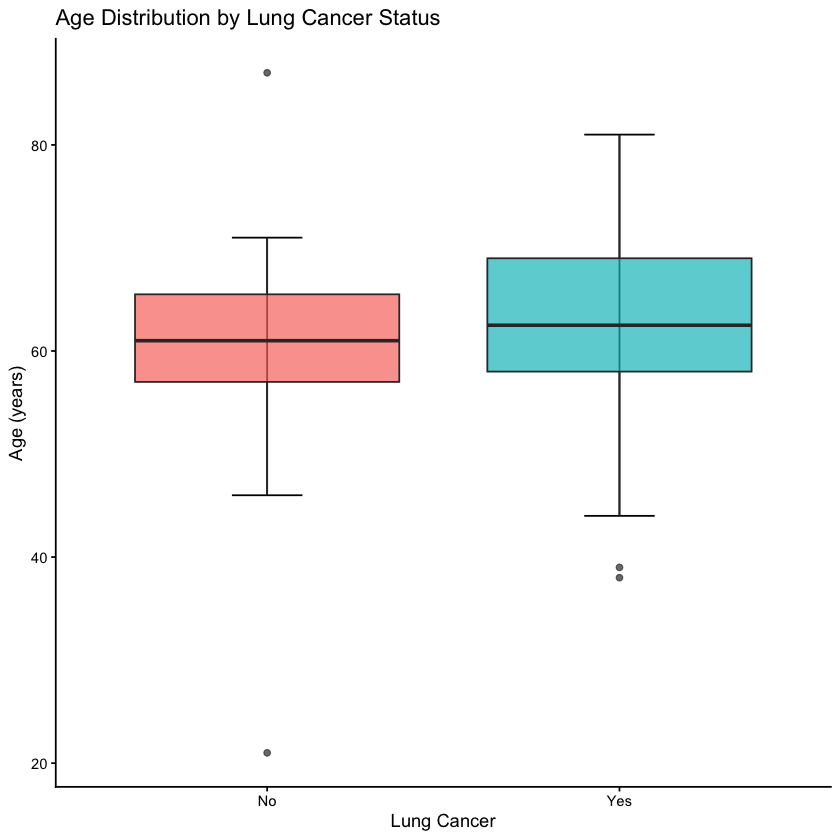

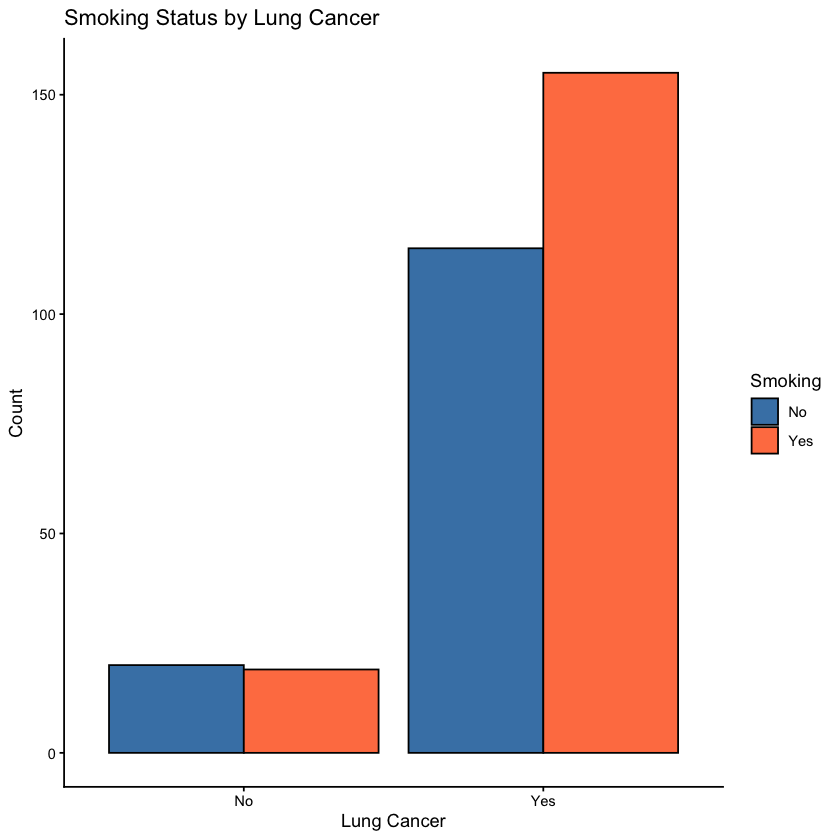

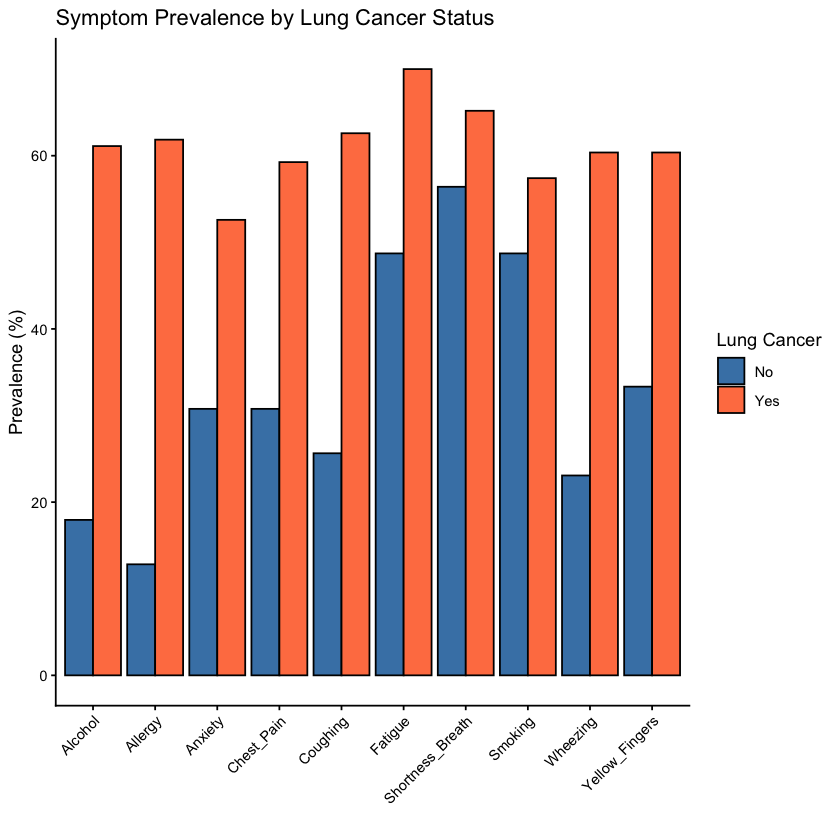

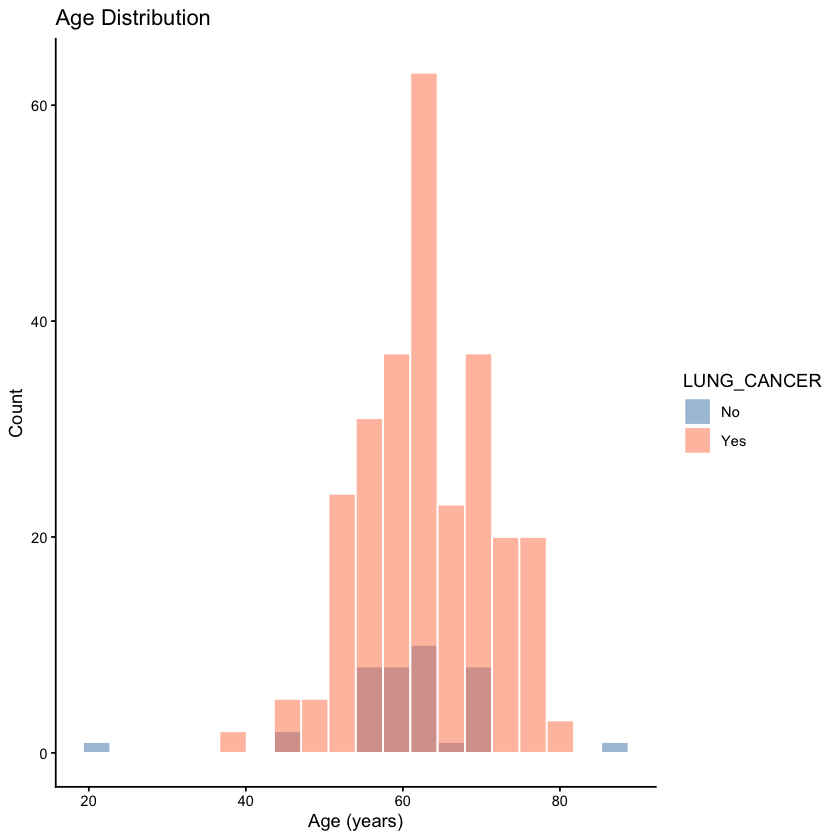

In [5]:
# ============================================================
# SECTION 3: Statistical plots
# Skill: medical-stat-stat-plot
# ============================================================

# 3.1 Boxplot: AGE by LUNG_CANCER
p1 <- ggplot(df, aes(LUNG_CANCER, AGE)) +
  stat_boxplot(geom = "errorbar", width = 0.2) +
  geom_boxplot(aes(fill = LUNG_CANCER), alpha = 0.7) +
  labs(x = "Lung Cancer", y = "Age (years)", title = "Age Distribution by Lung Cancer Status") +
  theme_classic() + theme(legend.position = "none")
ggsave(file.path(fig_dir, "boxplot_age_by_cancer.pdf"), p1, width = 6, height = 5)

# 3.2 Bar chart: Smoking status by LUNG_CANCER
smoking_tbl <- as.data.frame(table(df$SMOKING, df$LUNG_CANCER))
colnames(smoking_tbl) <- c("Smoking", "Cancer", "Count")
p2 <- ggplot(smoking_tbl, aes(Cancer, Count, fill = Smoking)) +
  geom_bar(stat = "identity", position = "dodge", color = "black") +
  scale_fill_manual(values = c("steelblue", "coral")) +
  labs(x = "Lung Cancer", y = "Count", fill = "Smoking", title = "Smoking Status by Lung Cancer") +
  theme_classic()
ggsave(file.path(fig_dir, "bar_smoking_by_cancer.pdf"), p2, width = 6, height = 5)

# 3.3 Stacked bar: symptom prevalence by LUNG_CANCER
symptom_prev <- df %>%
  group_by(LUNG_CANCER) %>%
  summarise(
    Smoking = mean(SMOKING == "Yes") * 100,
    Yellow_Fingers = mean(YELLOW_FINGERS == "Yes") * 100,
    Anxiety = mean(ANXIETY == "Yes") * 100,
    Coughing = mean(COUGHING == "Yes") * 100,
    Allergy = mean(ALLERGY == "Yes") * 100,
    Wheezing = mean(WHEEZING == "Yes") * 100,
    Fatigue = mean(FATIGUE == "Yes") * 100,
    Alcohol = mean(ALCOHOL_CONSUMING == "Yes") * 100,
    Chest_Pain = mean(CHEST_PAIN == "Yes") * 100,
    Shortness_Breath = mean(SHORTNESS_OF_BREATH == "Yes") * 100
  ) %>%
  pivot_longer(-LUNG_CANCER, names_to = "Symptom", values_to = "Prevalence")

p3 <- ggplot(symptom_prev, aes(Symptom, Prevalence, fill = LUNG_CANCER)) +
  geom_bar(stat = "identity", position = "dodge", color = "black") +
  scale_fill_manual(values = c("steelblue", "coral")) +
  labs(x = "", y = "Prevalence (%)", fill = "Lung Cancer", 
       title = "Symptom Prevalence by Lung Cancer Status") +
  theme_classic() + theme(axis.text.x = element_text(angle = 45, hjust = 1))
ggsave(file.path(fig_dir, "bar_symptoms_prevalence.pdf"), p3, width = 12, height = 6)

# 3.4 Histogram of AGE
p4 <- ggplot(df, aes(AGE, fill = LUNG_CANCER)) +
  geom_histogram(position = "identity", alpha = 0.5, bins = 20, color = "white") +
  scale_fill_manual(values = c("steelblue", "coral")) +
  labs(x = "Age (years)", y = "Count", title = "Age Distribution") +
  theme_classic()
ggsave(file.path(fig_dir, "hist_age.pdf"), p4, width = 6, height = 5)

# Display all plots
print(p1)
print(p2)
print(p3)
print(p4)

In [6]:
# ============================================================
# SECTION 4: T-test — Compare AGE between LUNG_CANCER groups
# Skill: medical-stat-ttest
# ============================================================

# 4.1 Normality test
cat("\n========== 4.1 Normality test (Shapiro-Wilk) ==========\n")
shapiro_no <- shapiro.test(df$AGE[df$LUNG_CANCER == "No"])
shapiro_yes <- shapiro.test(df$AGE[df$LUNG_CANCER == "Yes"])
cat(sprintf("Cancer=No:  W = %.4f, p = %.4f\n", shapiro_no$statistic, shapiro_no$p.value))
cat(sprintf("Cancer=Yes: W = %.4f, p = %.4f\n", shapiro_yes$statistic, shapiro_yes$p.value))

# 4.2 Variance homogeneity test
cat("\n========== 4.2 Variance test ==========\n")
var_test <- var.test(AGE ~ LUNG_CANCER, data = df)
cat(sprintf("F-test: F = %.4f, df = %d/%d, p = %.4f\n",
            var_test$statistic, var_test$parameter[1], var_test$parameter[2], var_test$p.value))

# 4.3 Independent t-test
cat("\n========== 4.3 Independent Two-Sample t-test ==========\n")

# Use Welch t-test (default, robust to unequal variances)
tt <- t.test(AGE ~ LUNG_CANCER, data = df, var.equal = FALSE)
cat(sprintf("Welch t-test: t = %.4f, df = %.1f, p = %.6f\n", 
            tt$statistic, tt$parameter, tt$p.value))
cat(sprintf("Mean difference: %.2f (95%% CI: %.2f – %.2f)\n", 
            diff(tt$estimate)[[1]], tt$conf.int[1], tt$conf.int[2]))
cat(sprintf("Mean AGE (No Cancer): %.2f ± %.2f\n", mean(age_no), sd(age_no)))
cat(sprintf("Mean AGE (Cancer):    %.2f ± %.2f\n", mean(age_yes), sd(age_yes)))

# 4.4 Export results
age_tt_result <- tidy(tt)
write.csv(age_tt_result, file.path(out_dir, "ttest_age_by_cancer.csv"), row.names = FALSE)
cat("\nT-test results saved.\n")


========== 4.1 Normality test (Shapiro-Wilk) ==========


Cancer=No:  W = 0.8338, p = 0.0000


Cancer=Yes: W = 0.9900, p = 0.0599



========== 4.2 Variance test ==========


F-test: F = 1.4610, df = 38/269, p = 0.0932


...

Welch t-test: t = -1.3662, df = 45.8, p = 0.178540


Mean difference: 2.21 (95% CI: -5.46 – 1.05)


Mean AGE (No Cancer): 60.74 ± 9.63


Mean AGE (Cancer):    62.95 ± 7.97



T-test results saved.


In [7]:
# ============================================================
# SECTION 5: Chi-square tests — Association of symptoms with LUNG_CANCER
# Skill: medical-stat-chisq
# ============================================================

cat("\n========== 5. Chi-Square Tests ==========\n")

chisq_results <- data.frame(
  Variable = character(),
  Chi_Sq = numeric(),
  df = integer(),
  p_value = numeric(),
  stringsAsFactors = FALSE
)

for (v in cat_vars) {
  tbl <- table(df[[v]], df$LUNG_CANCER)
  
  # Check expected frequencies
  expected <- chisq.test(tbl, correct = FALSE)$expected
  min_exp <- min(expected)
  
  if (v == "GENDER" && min_exp >= 5) {
    res <- chisq.test(tbl, correct = FALSE)
    method_note <- "Pearson"
  } else if (min_exp < 5 && all(dim(tbl) == c(2, 2))) {
    res <- fisher.test(tbl)
    method_note <- "Fisher"
  } else {
    res <- chisq.test(tbl, correct = FALSE)
    method_note <- "Pearson"
  }
  
  chisq_results <- rbind(chisq_results,
    data.frame(Variable = v,
               Test = method_note,
               Statistic = ifelse(method_note == "Fisher", 
                                   sprintf("OR=%.2f", res$estimate),
                                   sprintf("\u03C7\u00B2=%.2f", res$statistic)),
               p_value = res$p.value,
               stringsAsFactors = FALSE))
  
  cat(sprintf("%-30s %s  p = %s\n", v, method_note, 
              ifelse(res$p.value < 0.001, "<0.001", sprintf("%.4f", res$p.value))))
}

# Multiple comparison correction (Bonferroni)
chisq_results$p_adjusted <- p.adjust(chisq_results$p_value, method = "bonferroni")
cat("\n--- After Bonferroni correction ---\n")
for (i in 1:nrow(chisq_results)) {
  cat(sprintf("%-30s adjusted p = %s\n", chisq_results$Variable[i],
              ifelse(chisq_results$p_adjusted[i] < 0.001, "<0.001", sprintf("%.4f", chisq_results$p_adjusted[i]))))
}

write.csv(chisq_results, file.path(out_dir, "chisq_test_results.csv"), row.names = FALSE)
cat("\nChi-square results saved.\n")


========== 5. Chi-Square Tests ==========


GENDER                         Pearson  p = 0.2371
SMOKING                        Pearson  p = 0.3065
YELLOW_FINGERS                 Pearson  p = 0.0014
ANXIETY                        Pearson  p = 0.0108
PEER_PRESSURE                  Pearson  p = 0.0011
CHRONIC_DISEASE                Pearson  p = 0.0513
FATIGUE                        Pearson  p = 0.0081
ALLERGY                        Pearson  p = <0.001
WHEEZING                       Pearson  p = <0.001
ALCOHOL_CONSUMING              Pearson  p = <0.001
COUGHING                       Pearson  p = <0.001
SHORTNESS_OF_BREATH            Pearson  p = 0.2857
SWALLOWING_DIFFICULTY          Pearson  p = <0.001
CHEST_PAIN                     Pearson  p = <0.001



--- After Bonferroni correction ---


GENDER                         adjusted p = 1.0000
SMOKING                        adjusted p = 1.0000
YELLOW_FINGERS                 adjusted p = 0.0201
ANXIETY                        adjusted p = 0.1517
PEER_PRESSURE                  adjusted p = 0.0147
CHRONIC_DISEASE                adjusted p = 0.7177
FATIGUE                        adjusted p = 0.1132
ALLERGY                        adjusted p = <0.001
WHEEZING                       adjusted p = <0.001
ALCOHOL_CONSUMING              adjusted p = <0.001
COUGHING                       adjusted p = <0.001
SHORTNESS_OF_BREATH            adjusted p = 1.0000
SWALLOWING_DIFFICULTY          adjusted p = <0.001
CHEST_PAIN                     adjusted p = 0.0114



Chi-square results saved.



========== 6. Correlation Analysis ==========


pdf 
  2


--- Spearman correlations with AGE ---


COUGHING                  rho =  0.1760
SMOKING                   rho = -0.0763
WHEEZING                  rho =  0.0528
ANXIETY                   rho =  0.0477
ALLERGY                   rho =  0.0466
ALCOHOL_CONSUMING         rho =  0.0412
CHEST_PAIN                rho = -0.0273
FATIGUE                   rho =  0.0214
SWALLOWING_DIFFICULTY     rho = -0.0162
YELLOW_FINGERS            rho =  0.0157
PEER_PRESSURE             rho =  0.0132
CHRONIC_DISEASE           rho = -0.0079
SHORTNESS_OF_BREATH       rho = -0.0020



Correlation matrix saved.


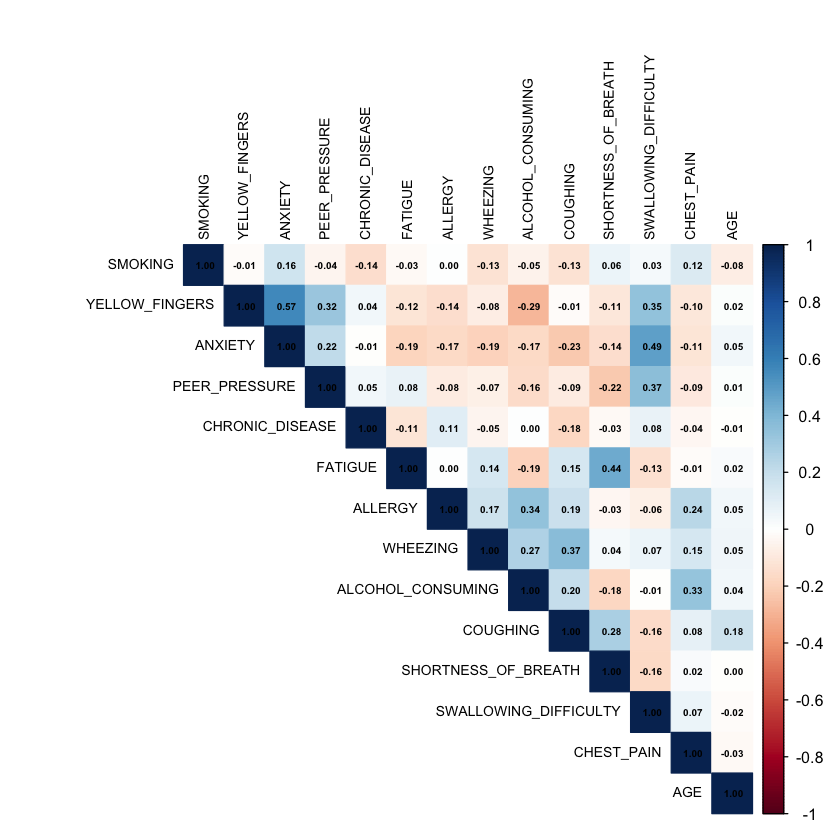

In [8]:
# ============================================================
# SECTION 6: Correlation analysis among symptoms
# Skill: medical-stat-correlation
# ============================================================

cat("\n========== 6. Correlation Analysis ==========\n")

# Create numeric matrix of symptoms
symp_vars <- binary_vars
symptom_num <- as.data.frame(lapply(df[, symp_vars], function(x) as.numeric(x) - 1))
symptom_num$AGE <- df$AGE

# 6.1 Spearman correlation matrix
cor_matrix <- cor(symptom_num, method = "spearman")

# 6.2 Visualize correlation matrix
pdf(file.path(fig_dir, "correlation_heatmap.pdf"), width = 10, height = 8)
corrplot(cor_matrix, method = "color", type = "upper",
         tl.col = "black", tl.cex = 0.7, 
         title = "Spearman Correlation among Symptoms",
         addCoef.col = "black", number.cex = 0.5,
         mar = c(0, 0, 2, 0))
dev.off()

# Display in notebook
corrplot(cor_matrix, method = "color", type = "upper",
         tl.col = "black", tl.cex = 0.7,
         addCoef.col = "black", number.cex = 0.5,
         mar = c(0, 0, 2, 0))

# 6.3 Top correlations with AGE
cat("\n--- Spearman correlations with AGE ---\n")
age_cor <- cor_matrix["AGE", symp_vars]
age_cor_sorted <- sort(abs(age_cor), decreasing = TRUE)
for (i in 1:length(age_cor_sorted)) {
  v <- names(age_cor_sorted)[i]
  cat(sprintf("%-25s rho = % .4f\n", v, age_cor[v]))
}

write.csv(as.data.frame(cor_matrix), file.path(out_dir, "correlation_matrix.csv"))
cat("\nCorrelation matrix saved.\n")

In [9]:
# ============================================================
# SECTION 7: Logistic Regression — Predicting LUNG_CANCER
# Skill: medical-stat-logistic-reg
# ============================================================

cat("\n========== 7.1 Univariate Logistic Regression ==========\n")

# Ensure numeric versions for modeling
for (v in symp_vars) {
  df[[paste0(v, "_num")]] <- as.numeric(df[[v]]) - 1  # 0 = No, 1 = Yes
}
df$GENDER_num <- as.numeric(df$GENDER) - 1  # 0 = Female, 1 = Male

univar_vars <- c("AGE", "GENDER_num", paste0(symp_vars, "_num"))
univar_labels <- c("AGE", "GENDER (Male)", symp_vars)

univar_results <- data.frame(
  Variable = character(),
  OR = numeric(),
  CI_low = numeric(),
  CI_up = numeric(),
  p_value = numeric(),
  stringsAsFactors = FALSE
)

for (i in 1:length(univar_vars)) {
  formula_str <- paste0("LUNG_CANCER ~ ", univar_vars[i])
  fit <- glm(as.formula(formula_str), data = df, family = binomial())
  tidy_res <- tidy(fit, conf.int = TRUE, exponentiate = TRUE)
  
  # Get the coefficient row (not intercept)
  res_row <- tidy_res[2, ]
  
  univar_results <- rbind(univar_results,
    data.frame(Variable = univar_labels[i],
               OR = res_row$estimate,
               CI_low = res_row$conf.low,
               CI_up = res_row$conf.high,
               p_value = res_row$p.value,
               stringsAsFactors = FALSE))
  
  cat(sprintf("%-30s OR = %7.2f (95%% CI: %7.2f – %7.2f) p = %s\n",
              univar_labels[i], res_row$estimate, res_row$conf.low, res_row$conf.high,
              ifelse(res_row$p.value < 0.001, "<0.001", sprintf("%.4f", res_row$p.value))))
}

write.csv(univar_results, file.path(out_dir, "univariate_logistic_regression.csv"), row.names = FALSE)


========== 7.1 Univariate Logistic Regression ==========


AGE                            OR =    1.03 (95% CI:    0.99 –    1.07) p = 0.1179


GENDER (Male)                  OR =    1.50 (95% CI:    0.77 –    2.99) p = 0.2393


SMOKING                        OR =    1.42 (95% CI:    0.72 –    2.80) p = 0.3081


YELLOW_FINGERS                 OR =    3.05 (95% CI:    1.52 –    6.37) p = 0.0021


...

ALCOHOL_CONSUMING              OR =    7.18 (95% CI:    3.23 –   18.26) p = <0.001


COUGHING                       OR =    4.85 (95% CI:    2.34 –   10.86) p = <0.001


SHORTNESS_OF_BREATH            OR =    1.45 (95% CI:    0.72 –    2.85) p = 0.2875


SWALLOWING_DIFFICULTY          OR =    7.32 (95% CI:    3.03 –   21.86) p = <0.001


CHEST_PAIN                     OR =    3.27 (95% CI:    1.62 –    6.96) p = 0.0013


In [10]:
# ============================================================
# 7.2 Multivariate Logistic Regression
# ============================================================
cat("\n========== 7.2 Multivariate Logistic Regression ==========\n")

# Full model with all predictors
full_formula <- as.formula(paste0("LUNG_CANCER ~ AGE + GENDER_num + ",
                                   paste(paste0(symp_vars, "_num"), collapse = " + ")))
full_fit <- glm(full_formula, data = df, family = binomial())
cat("\n--- Full Model Summary ---\n")
summary(full_fit)

# Model evaluation
cat("\n--- Model Evaluation ---\n")
null_fit <- glm(LUNG_CANCER ~ 1, data = df, family = binomial())
cat(sprintf("Null deviance: %.2f\n", null_fit$deviance))
cat(sprintf("Residual deviance: %.2f\n", full_fit$deviance))
cat(sprintf("AIC: %.2f\n", AIC(full_fit)))

# Likelihood ratio test
lr_test <- anova(null_fit, full_fit, test = "Chisq")
cat(sprintf("Likelihood ratio test: Chi-sq = %.2f, df = %d, p = %s\n",
            lr_test$Deviance[2], lr_test$Df[2],
            ifelse(lr_test$`Pr(>Chi)`[2] < 0.001, "<0.001", 
                   sprintf("%.6f", lr_test$`Pr(>Chi)`[2]))))

# Stepwise selection (backward)
cat("\n--- Stepwise Backward Selection ---\n")
step_fit <- step(full_fit, direction = "backward", trace = 0)
cat("Selected model:\n")
summary(step_fit)

# Final multivariate results
multivar_res <- tidy(step_fit, conf.int = TRUE, exponentiate = TRUE)
multivar_res <- subset(multivar_res, term != "(Intercept)")
print(multivar_res)

write.csv(multivar_res, file.path(out_dir, "multivariate_logistic_regression.csv"), row.names = FALSE)
cat("\nMultivariate results saved.\n")


========== 7.2 Multivariate Logistic Regression ==========



--- Full Model Summary ---



Call:
glm(formula = full_formula, family = binomial(), data = df)

Deviance Residuals: 
     Min        1Q    Median        3Q       Max  
-2.19285   0.01489   0.06721   0.16744   2.39827  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -8.33760    2.50692  -3.326 0.000882 ***
AGE                        0.02181    0.03394   0.643 0.520476    
GENDER_num                -0.52611    0.70898  -0.742 0.458050    
SMOKING_num                1.77601    0.70190   2.530 0.011396 *  
YELLOW_FINGERS_num         1.37642    0.74251   1.854 0.063776 .  
ANXIETY_num                0.88775    0.81268   1.092 0.274671    
PEER_PRESSURE_num          1.73122    0.66025   2.622 0.008740 ** 
CHRONIC_DISEASE_num        3.19156    0.88829   3.593 0.000327 ***
FATIGUE_num                3.07043    0.82520   3.721 0.000199 ***
ALLERGY_num                1.64614    0.76894   2.141 0.032291 *  
WHEEZING_num               0.96625    0.83419   1.158 0.2


--- Model Evaluation ---


Null deviance: 234.30


...


--- Stepwise Backward Selection ---


Selected model:



Call:
glm(formula = LUNG_CANCER ~ SMOKING_num + YELLOW_FINGERS_num + 
    PEER_PRESSURE_num + CHRONIC_DISEASE_num + FATIGUE_num + ALLERGY_num + 
    ALCOHOL_CONSUMING_num + COUGHING_num + SWALLOWING_DIFFICULTY_num, 
    family = binomial(), data = df)

Deviance Residuals: 
     Min        1Q    Median        3Q       Max  
-2.39797   0.01515   0.06230   0.18836   2.25582  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                -6.6110     1.2677  -5.215 1.84e-07 ***
SMOKING_num                 1.4536     0.6535   2.224 0.026120 *  
YELLOW_FINGERS_num          1.7409     0.6397   2.722 0.006497 ** 
PEER_PRESSURE_num           1.8743     0.6372   2.942 0.003265 ** 
CHRONIC_DISEASE_num         2.6949     0.7619   3.537 0.000404 ***
FATIGUE_num                 2.8705     0.6719   4.272 1.94e-05 ***
ALLERGY_num                 1.8342     0.7238   2.534 0.011267 *  
ALCOHOL_CONSUMING_num       1.7514     0.7117   2.461 0.013861 *  
COUGH

# A tibble: 9 × 7
  term                   estimate std.error statistic p.value conf.low conf.high
  <chr>                     <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 SMOKING_num                4.28     0.653      2.22 2.61e-2     1.25      16.7
2 YELLOW_FINGERS_num         5.70     0.640      2.72 6.50e-3     1.76      22.3
3 PEER_PRESSURE_num          6.52     0.637      2.94 3.27e-3     2.02      25.3
4 CHRONIC_DISEASE_num       14.8      0.762      3.54 4.04e-4     3.74      77.3
5 FATIGUE_num               17.6      0.672      4.27 1.94e-5     5.19      74.8
6 ALLERGY_num                6.26     0.724      2.53 1.13e-2     1.58      28.2
7 ALCOHOL_CONSUMING_num      5.76     0.712      2.46 1.39e-2     1.51      25.5
8 COUGHING_num              21.4      0.837      3.66 2.50e-4     4.56     126. 
9 SWALLOWING_DIFFICULTY…    30.8      0.980      3.50 4.69e-4     5.24     253. 



Multivariate results saved.



========== 7.3 Forest Plot (Univariate) ==========


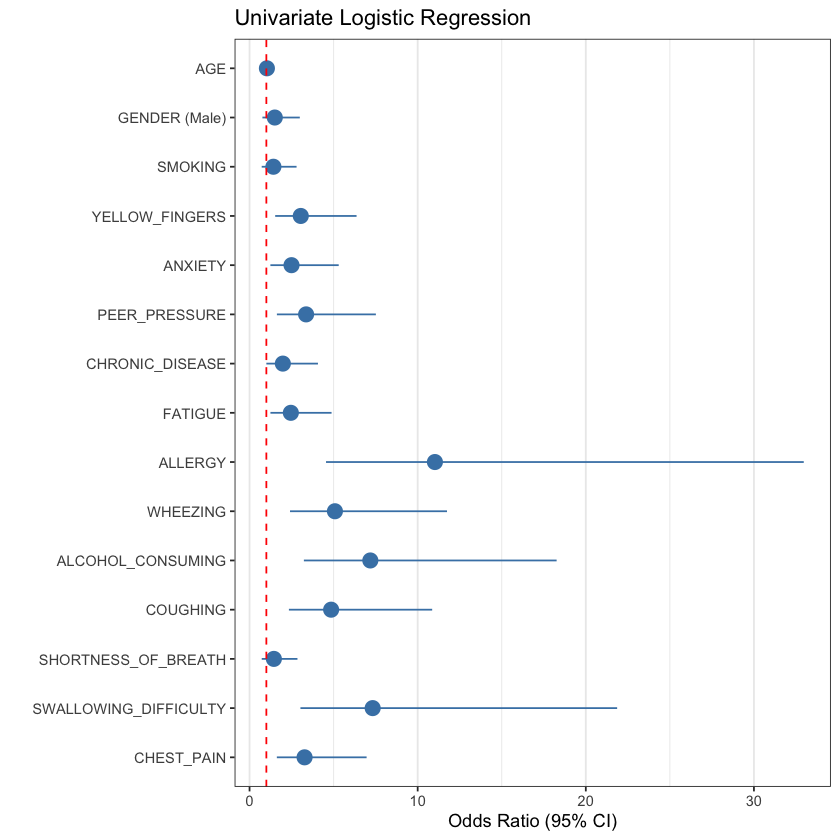

In [11]:
# ============================================================
# 7.3 Univariate Forest Plot
# ============================================================
cat("\n========== 7.3 Forest Plot (Univariate) ==========\n")

fp_data <- univar_results
fp_data$Variable <- factor(fp_data$Variable, levels = rev(fp_data$Variable))

p_forest <- ggplot(fp_data, aes(x = Variable, y = OR, ymin = CI_low, ymax = CI_up)) +
  geom_pointrange(size = 0.8, color = "steelblue") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(x = "", y = "Odds Ratio (95% CI)", title = "Univariate Logistic Regression") +
  theme_bw() +
  theme(panel.grid.major.y = element_blank())

ggsave(file.path(fig_dir, "forest_plot_univariate.pdf"), p_forest, width = 8, height = 8)
print(p_forest)


========== 8. ROC Analysis ==========



AUC = 0.9646 (95% CI: 0.9447 – 0.9846)



--- Best Threshold (Youden Index) ---


threshold      : 0.9151
sensitivity    : 0.863
specificity    : 0.9744
ppv            : 0.9957
npv            : 0.5067
tp             : 233
tn             : 38
fp             : 1
fn             : 37


pdf 
  2


--- ROC for Individual Symptoms ---


SMOKING: AUC = 0.5434


COUGHING: AUC = 0.6848


ALLERGY: AUC = 0.7452



ROC results saved.


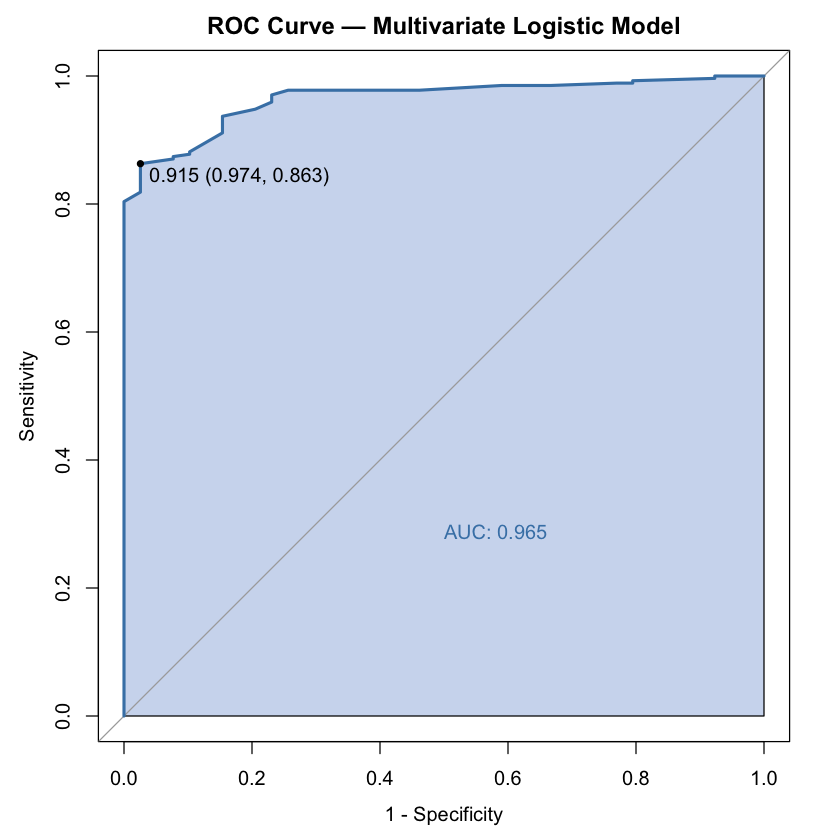

In [12]:
# ============================================================
# SECTION 8: ROC Analysis — Evaluate prediction performance
# Skill: medical-stat-roc
# ============================================================

cat("\n========== 8. ROC Analysis ==========\n")

# Predict probabilities from the stepwise model
df$pred_prob <- predict(step_fit, type = "response")

# 8.1 Overall ROC
roc_obj <- roc(df$LUNG_CANCER, df$pred_prob, levels = c("No", "Yes"), direction = "<")
cat(sprintf("\nAUC = %.4f (95%% CI: %.4f – %.4f)\n", 
            auc(roc_obj), ci.auc(roc_obj)[1], ci.auc(roc_obj)[3]))

# 8.2 Find best threshold (Youden index)
best_coords <- coords(roc_obj, "best", ret = c("threshold", "sensitivity", "specificity", 
                                                  "ppv", "npv", "tp", "tn", "fp", "fn"))
cat("\n--- Best Threshold (Youden Index) ---\n")
for (nm in names(best_coords)) {
  cat(sprintf("%-15s: %s\n", nm, format(round(as.numeric(best_coords[nm]), 4))))
}

# 8.3 Plot ROC curve
pdf(file.path(fig_dir, "roc_curve_multivariable.pdf"), width = 7, height = 6)
plot(roc_obj, col = "steelblue", lwd = 2.5, main = "ROC Curve — Multivariate Logistic Model",
     auc.polygon = TRUE, auc.polygon.col = rgb(0.3, 0.5, 0.8, 0.3),
     print.auc = TRUE, print.auc.x = 0.5, print.auc.y = 0.3,
     print.thres = "best", legacy.axes = TRUE)
dev.off()

# Display
plot(roc_obj, col = "steelblue", lwd = 2.5, main = "ROC Curve — Multivariate Logistic Model",
     auc.polygon = TRUE, auc.polygon.col = rgb(0.3, 0.5, 0.8, 0.3),
     print.auc = TRUE, print.auc.x = 0.5, print.auc.y = 0.3,
     print.thres = "best", legacy.axes = TRUE)

# 8.4 ROC for selected individual symptoms
cat("\n--- ROC for Individual Symptoms ---\n")
roc_smoking <- roc(df$LUNG_CANCER, as.numeric(df$SMOKING_num), 
                    levels = c("No", "Yes"), direction = "<")
roc_coughing <- roc(df$LUNG_CANCER, as.numeric(df$COUGHING_num),
                     levels = c("No", "Yes"), direction = "<")
roc_allergy <- roc(df$LUNG_CANCER, as.numeric(df$ALLERGY_num),
                    levels = c("No", "Yes"), direction = "<")

cat(sprintf("SMOKING: AUC = %.4f\n", auc(roc_smoking)))
cat(sprintf("COUGHING: AUC = %.4f\n", auc(roc_coughing)))
cat(sprintf("ALLERGY: AUC = %.4f\n", auc(roc_allergy)))

# Save ROC metrics
roc_metrics <- data.frame(
  Metric = c("AUC", "AUC_CI_low", "AUC_CI_up", names(best_coords)),
  Value = c(auc(roc_obj), ci.auc(roc_obj)[1], ci.auc(roc_obj)[3], as.numeric(best_coords))
)
write.csv(roc_metrics, file.path(out_dir, "roc_analysis.csv"), row.names = FALSE)
cat("\nROC results saved.\n")

In [13]:
# ============================================================
# SECTION 9: Principal Component Analysis (PCA)
# Skills: medical-stat-pca, medical-stat-pca-vis
# ============================================================

cat("\n========== 9. PCA Analysis ==========\n")

# Use numeric symptom matrix + AGE for PCA
pca_data <- symptom_num

# 9.1 KMO and Bartlett test
cat("\n--- 9.1 Bartlett test ---\n")
cortest_res <- cor(pca_data)
n <- nrow(pca_data)
p <- ncol(pca_data)
# Simple Bartlett test implementation
det_R <- det(cortest_res)
trace_R <- sum(diag(cortest_res))
bartlett_stat <- -(n - 1 - (2 * p + 5) / 6) * log(det_R / (trace_R / p)^p)
bartlett_df <- p * (p - 1) / 2
bartlett_p <- pchisq(bartlett_stat, bartlett_df, lower.tail = FALSE)
cat(sprintf("Bartlett test: Chi-sq = %.2f, df = %d, p = %s\n",
            bartlett_stat, bartlett_df,
            ifelse(bartlett_p < 0.001, "<0.001", sprintf("%.6f", bartlett_p))))

# 9.2 KMO (simplified using correlation magnitudes)
cor_abs <- abs(cortest_res)
diag(cor_abs) <- NA
cat(sprintf("Mean absolute correlation (off-diagonal): %.4f\n", mean(cor_abs, na.rm = TRUE)))
cat(sprintf("Min correlation: %.4f, Max correlation: %.4f\n", 
            min(cor_abs, na.rm = TRUE), max(cor_abs, na.rm = TRUE)))

# 9.3 Perform PCA
pca_res <- prcomp(pca_data, scale. = TRUE, center = TRUE)

cat("\n--- 9.3 PCA Summary ---\n")
summary(pca_res)

cat("\nEigenvalues:\n")
eig_vals <- pca_res$sdev^2
for (i in 1:length(eig_vals)) {
  cat(sprintf("PC%d: %.4f\n", i, eig_vals[i]))
}


========== 9. PCA Analysis ==========



--- 9.1 Bartlett test ---


Bartlett test: Chi-sq = 771.08, df = 91, p = <0.001


Mean absolute correlation (off-diagonal): 0.1294


Min correlation: 0.0013, Max correlation: 0.5658



--- 9.3 PCA Summary ---


Importance of components:
                          PC1    PC2    PC3     PC4     PC5     PC6     PC7
Standard deviation     1.6336 1.3427 1.2387 1.12863 1.04601 0.98136 0.94365
Proportion of Variance 0.1906 0.1288 0.1096 0.09099 0.07815 0.06879 0.06361
Cumulative Proportion  0.1906 0.3194 0.4290 0.51997 0.59812 0.66691 0.73052
                           PC8     PC9    PC10    PC11    PC12    PC13    PC14
Standard deviation     0.88419 0.84064 0.78745 0.75715 0.68529 0.57628 0.53780
Proportion of Variance 0.05584 0.05048 0.04429 0.04095 0.03354 0.02372 0.02066
Cumulative Proportion  0.78636 0.83684 0.88113 0.92208 0.95562 0.97934 1.00000


Eigenvalues:


PC1: 2.6686
PC2: 1.8029
PC3: 1.5343
PC4: 1.2738
PC5: 1.0941
PC6: 0.9631
PC7: 0.8905
PC8: 0.7818
PC9: 0.7067
PC10: 0.6201
PC11: 0.5733
PC12: 0.4696
PC13: 0.3321
PC14: 0.2892



========== 9.4 Scree Plot ==========



Cumulative variance explained by first 3 PCs: 42.9%


Cumulative variance explained by first 5 PCs: 59.8%


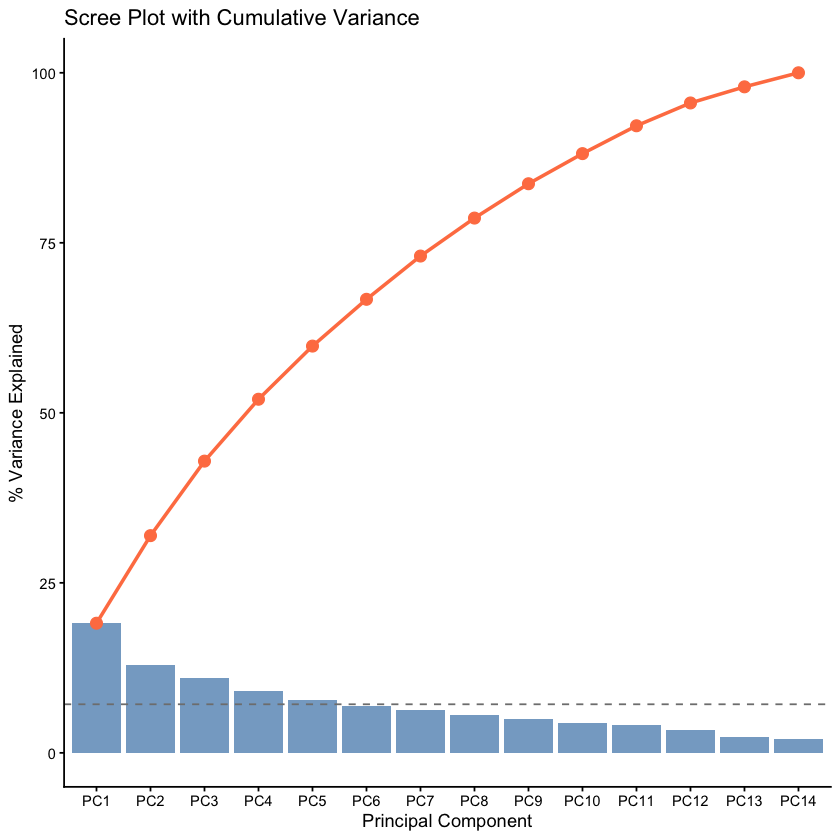

In [14]:
# 9.4 Scree plot
cat("\n========== 9.4 Scree Plot ==========\n")
var_explained <- pca_res$sdev^2 / sum(pca_res$sdev^2) * 100
cum_var <- cumsum(var_explained)

scree_df <- data.frame(PC = paste0("PC", 1:length(var_explained)),
                        Variance = var_explained,
                        Cumulative = cum_var)
scree_df$PC <- factor(scree_df$PC, levels = scree_df$PC)

p_scree <- ggplot(scree_df, aes(PC, Variance)) +
  geom_bar(stat = "identity", fill = "steelblue", alpha = 0.7) +
  geom_line(aes(y = Cumulative, group = 1), color = "coral", linewidth = 1) +
  geom_point(aes(y = Cumulative), color = "coral", size = 3) +
  geom_hline(yintercept = 100 / ncol(pca_data), linetype = "dashed", color = "gray50") +
  labs(x = "Principal Component", y = "% Variance Explained", 
       title = "Scree Plot with Cumulative Variance") +
  theme_classic()
ggsave(file.path(fig_dir, "pca_scree_plot.pdf"), p_scree, width = 8, height = 5)
print(p_scree)

cat(sprintf("\nCumulative variance explained by first 3 PCs: %.1f%%\n", cum_var[3]))
cat(sprintf("Cumulative variance explained by first 5 PCs: %.1f%%\n", cum_var[5]))

In [15]:
# 9.5 PCA Loadings
cat("\n========== 9.5 PCA Loadings (Rotation Matrix) ==========\n")

# Extract loadings (use rotation as loadings)
loadings <- as.data.frame(pca_res$rotation[, 1:5])
loadings$Variable <- rownames(loadings)
print(round(as.data.frame(pca_res$rotation[, 1:5]), 3))

# Variable importance for PC1 and PC2
cat("\n--- Top contributors to PC1 ---\n")
pc1_loadings <- abs(pca_res$rotation[, 1])
pc1_contrib <- pc1_loadings / sum(pc1_loadings) * 100
pc1_sorted <- sort(pc1_contrib, decreasing = TRUE)
for (i in 1:min(5, length(pc1_sorted))) {
  cat(sprintf("%-25s %.1f%%\n", names(pc1_sorted)[i], pc1_sorted[i]))
}

cat("\n--- Top contributors to PC2 ---\n")
pc2_loadings <- abs(pca_res$rotation[, 2])
pc2_contrib <- pc2_loadings / sum(pc2_loadings) * 100
pc2_sorted <- sort(pc2_contrib, decreasing = TRUE)
for (i in 1:min(5, length(pc2_sorted))) {
  cat(sprintf("%-25s %.1f%%\n", names(pc2_sorted)[i], pc2_sorted[i]))
}

write.csv(loadings, file.path(out_dir, "pca_loadings.csv"), row.names = FALSE)


========== 9.5 PCA Loadings (Rotation Matrix) ==========


                         PC1    PC2    PC3    PC4    PC5
SMOKING                0.068 -0.040  0.162 -0.687  0.032
YELLOW_FINGERS         0.407  0.040 -0.334 -0.022  0.031
ANXIETY                0.457  0.107 -0.162 -0.215  0.117
PEER_PRESSURE          0.309  0.069 -0.288  0.132 -0.235
CHRONIC_DISEASE        0.069  0.120  0.147  0.404 -0.569
FATIGUE               -0.171 -0.403 -0.348 -0.081 -0.331
ALLERGY               -0.245  0.344 -0.045 -0.044 -0.273
WHEEZING              -0.252  0.217 -0.417  0.051 -0.037
ALCOHOL_CONSUMING     -0.273  0.508  0.047 -0.042  0.073
COUGHING              -0.307  0.025 -0.478  0.026  0.230
SHORTNESS_OF_BREATH   -0.209 -0.429 -0.246 -0.215 -0.222
SWALLOWING_DIFFICULTY  0.346  0.286 -0.284 -0.133 -0.204
CHEST_PAIN            -0.185  0.330 -0.036 -0.422 -0.226
AGE                   -0.035  0.076 -0.249  0.211  0.469



--- Top contributors to PC1 ---


ANXIETY                   13.7%
YELLOW_FINGERS            12.2%
SWALLOWING_DIFFICULTY     10.4%
PEER_PRESSURE             9.3%
COUGHING                  9.2%



--- Top contributors to PC2 ---


ALCOHOL_CONSUMING         17.0%
SHORTNESS_OF_BREATH       14.3%
FATIGUE                   13.5%
ALLERGY                   11.5%
CHEST_PAIN                11.0%



========== 9.6 PCA Score Plot ==========


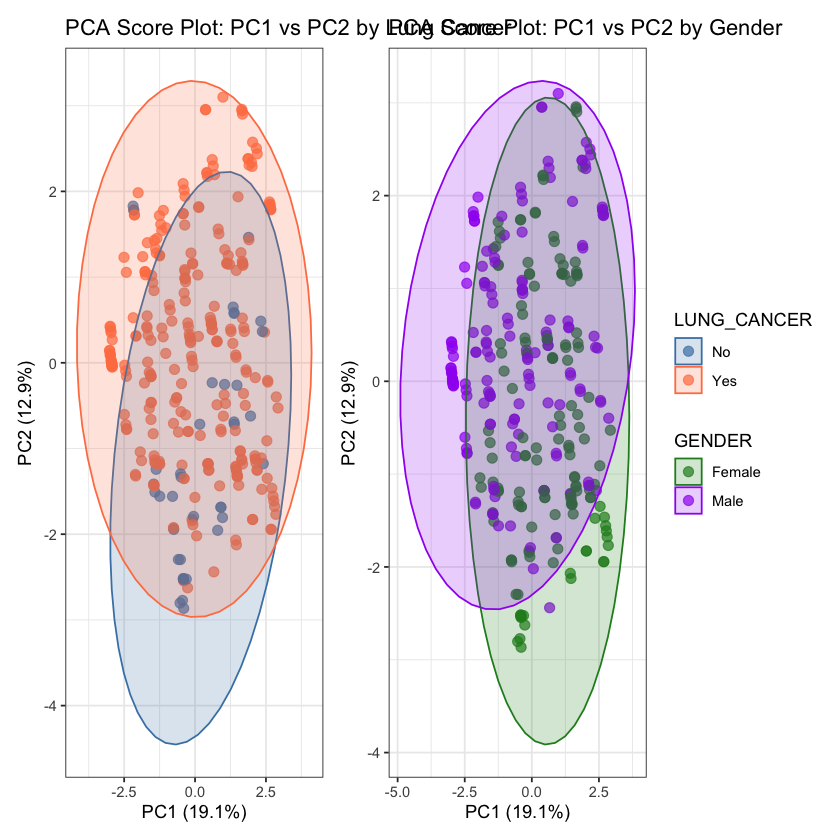

In [16]:
# 9.6 PCA Score Plot (Sample distribution)
cat("\n========== 9.6 PCA Score Plot ==========\n")

scores <- as.data.frame(pca_res$x)
scores$LUNG_CANCER <- df$LUNG_CANCER
scores$GENDER <- df$GENDER

# PC1 vs PC2 by LUNG_CANCER
p_pca1 <- ggplot(scores, aes(PC1, PC2, color = LUNG_CANCER, fill = LUNG_CANCER)) +
  geom_point(size = 2.5, alpha = 0.7) +
  stat_ellipse(alpha = 0.2, geom = "polygon", type = "norm") +
  scale_color_manual(values = c("steelblue", "coral")) +
  scale_fill_manual(values = c("steelblue", "coral")) +
  labs(x = sprintf("PC1 (%.1f%%)", var_explained[1]),
       y = sprintf("PC2 (%.1f%%)", var_explained[2]),
       title = "PCA Score Plot: PC1 vs PC2 by Lung Cancer") +
  theme_bw()
ggsave(file.path(fig_dir, "pca_score_by_cancer.pdf"), p_pca1, width = 8, height = 6)

# PC1 vs PC2 by GENDER
p_pca2 <- ggplot(scores, aes(PC1, PC2, color = GENDER, fill = GENDER)) +
  geom_point(size = 2.5, alpha = 0.7) +
  stat_ellipse(alpha = 0.2, geom = "polygon", type = "norm") +
  scale_color_manual(values = c("forestgreen", "purple")) +
  scale_fill_manual(values = c("forestgreen", "purple")) +
  labs(x = sprintf("PC1 (%.1f%%)", var_explained[1]),
       y = sprintf("PC2 (%.1f%%)", var_explained[2]),
       title = "PCA Score Plot: PC1 vs PC2 by Gender") +
  theme_bw()
ggsave(file.path(fig_dir, "pca_score_by_gender.pdf"), p_pca2, width = 8, height = 6)

# Combined
p_pca_combined <- p_pca1 + p_pca2 + plot_layout(guides = "collect")
print(p_pca_combined)


========== 9.7 PCA Biplot ==========



PCA analysis complete. All plots saved to: /Users/leigao/Documents/R-Medical-Statistics-Skills/example/lung-cancer/data/analysis/figures 


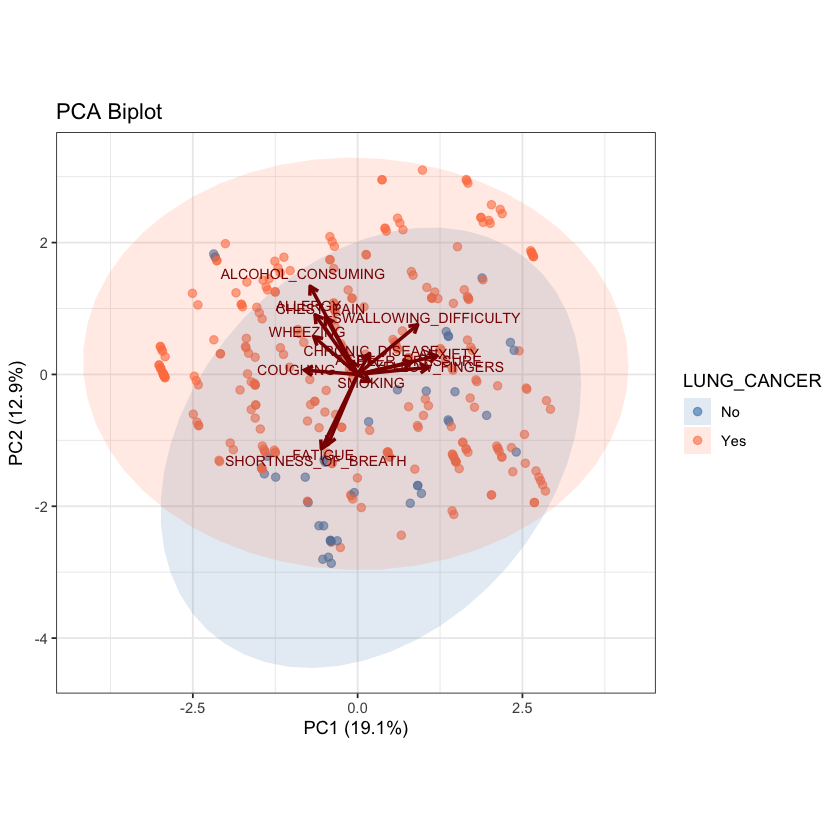

In [17]:
# 9.7 PCA Biplot (custom with ggplot2)
cat("\n========== 9.7 PCA Biplot ==========\n")

# Get loading coordinates (scaled for biplot)
loadings_scaled <- as.data.frame(pca_res$rotation[, 1:2] * max(abs(scores[, 1:2])) * 0.85)
loadings_scaled$Variable <- rownames(loadings_scaled)

p_biplot <- ggplot(scores, aes(PC1, PC2)) +
  geom_point(aes(color = LUNG_CANCER), size = 2, alpha = 0.6) +
  stat_ellipse(aes(fill = LUNG_CANCER), alpha = 0.15, geom = "polygon", type = "norm") +
  geom_segment(data = loadings_scaled, 
               aes(x = 0, y = 0, xend = PC1, yend = PC2),
               arrow = arrow(length = unit(0.2, "cm")), color = "darkred", linewidth = 1) +
  geom_text(data = loadings_scaled, aes(x = PC1 * 1.15, y = PC2 * 1.15, label = Variable),
            color = "darkred", size = 3) +
  scale_color_manual(values = c("steelblue", "coral")) +
  scale_fill_manual(values = c("steelblue", "coral")) +
  labs(x = sprintf("PC1 (%.1f%%)", var_explained[1]),
       y = sprintf("PC2 (%.1f%%)", var_explained[2]),
       title = "PCA Biplot"
  ) +
  coord_fixed() +
  theme_bw()

ggsave(file.path(fig_dir, "pca_biplot.pdf"), p_biplot, width = 10, height = 8)
print(p_biplot)

cat("\nPCA analysis complete. All plots saved to:", fig_dir, "\n")

In [18]:
# ============================================================
# SECTION 10: Summary and Export
# ============================================================

cat("\n")
cat(paste(rep("=", 70), collapse = ""), "\n")
cat("ANALYSIS COMPLETE\n")
cat(paste(rep("=", 70), collapse = ""), "\n")

cat("\n--- Key Findings ---\n")

# Summarize
cat(sprintf("\n1. Sample size: %d (Lung Cancer: %d Yes, %d No)\n",
            nrow(df), sum(df$LUNG_CANCER == "Yes"), sum(df$LUNG_CANCER == "No")))

cat(sprintf("2. Age comparison: p = %s (t-test)\n", 
            ifelse(tt$p.value < 0.001, "<0.001", sprintf("%.4f", tt$p.value))))

cat("3. Significant univariate predictors (p < 0.05):\n")
sig_vars <- subset(univar_results, p_value < 0.05)
for (i in 1:nrow(sig_vars)) {
  cat(sprintf("   %-30s OR = %7.2f (p = %s)\n",
              sig_vars$Variable[i], sig_vars$OR[i],
              ifelse(sig_vars$p_value[i] < 0.001, "<0.001", sprintf("%.4f", sig_vars$p_value[i]))))
}

cat(sprintf("\n4. Multivariate model AUC: %.4f (95%% CI: %.4f – %.4f)\n",
            auc(roc_obj), ci.auc(roc_obj)[1], ci.auc(roc_obj)[3]))

cat(sprintf("\n5. PCA: first 3 PCs explain %.1f%% of total variance\n", cum_var[3]))

cat("\n--- Output Files ---\n")
out_files <- list.files(out_dir, recursive = TRUE)
for (f in sort(out_files)) {
  cat(sprintf("  %s\n", f))
}

cat("\nAnalysis finished successfully.\n")

ANALYSIS COMPLETE



--- Key Findings ---



1. Sample size: 309 (Lung Cancer: 270 Yes, 39 No)


2. Age comparison: p = 0.1785 (t-test)


3. Significant univariate predictors (p < 0.05):


...


4. Multivariate model AUC: 0.9646 (95% CI: 0.9447 – 0.9846)



5. PCA: first 3 PCs explain 42.9% of total variance



--- Output Files ---


  chisq_test_results.csv
  correlation_matrix.csv
  figures/bar_smoking_by_cancer.pdf
  figures/bar_symptoms_prevalence.pdf
  figures/boxplot_age_by_cancer.pdf
  figures/correlation_heatmap.pdf
  figures/forest_plot_univariate.pdf
  figures/hist_age.pdf
  figures/pca_biplot.pdf
  figures/pca_score_by_cancer.pdf
  figures/pca_score_by_gender.pdf
  figures/pca_scree_plot.pdf
  figures/roc_curve_multivariable.pdf
  lung_cancer_analysis.ipynb
  multivariate_logistic_regression.csv
  pca_loadings.csv
  roc_analysis.csv
  table1_baseline_characteristics.csv
  ttest_age_by_cancer.csv
  univariate_logistic_regression.csv



Analysis finished successfully.
